In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import os
import sys
import matplotlib.pyplot as plt

In [17]:
sys.path.append(os.path.abspath(os.path.join('..')))

In [18]:
from models.baseline_model import BaselineModel
from models.improved_model import Improved_Model
from models.pretrained_model import get_resnet_model

In [19]:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [20]:
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

augmented_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [21]:
simple_train_set = datasets.ImageFolder(root='../../data/processed_data/train', transform=simple_transform)
simple_val_set = datasets.ImageFolder(root='../../data/processed_data/val', transform=simple_transform)
augmented_train_set = datasets.ImageFolder(root='../../data/processed_data/train', transform=augmented_transform)
augmented_val_set = datasets.ImageFolder(root='../../data/processed_data/val', transform=augmented_transform)

test_set = datasets.ImageFolder(root='../../data/processed_data/test')

simple_train_loader = DataLoader(simple_train_set, batch_size=BATCH_SIZE, shuffle=True)
simple_val_loader = DataLoader(simple_val_set, batch_size=BATCH_SIZE, shuffle=False)

augmented_train_loader = DataLoader(augmented_train_set, batch_size=BATCH_SIZE, shuffle=True)
augmented_val_loader = DataLoader(augmented_val_set, batch_size=BATCH_SIZE, shuffle=False)

test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [22]:
def train_model(model, model_name, train_loader, val_loader, epochs, lr, isScheduler=False):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    scheduler = None
    if (isScheduler):
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    
    best_acc = 0.0
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        running_loss = 0.0
        
        train_bar = tqdm(train_loader, desc=f"{model_name} - Epoch {epoch+1}/{epochs}")
        
        for images, labels in train_bar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            train_bar.set_postfix(loss=loss.item())

        avg_loss = running_loss / len(train_loader)
        
        # --- VALIDATION ---
        model.eval()
        correct, total = 0, 0

        val_bar = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}] Val", unit="batch", leave=False)
        
        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total

        if scheduler is not None:
            scheduler.step(val_acc)
        
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Result: Loss {avg_loss:.4f} | Val Acc {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model, f"{model_name}.pt")
            print(f"Saved Best {model_name} with {val_acc:.2f}% accuracy")
            
    return history

In [23]:
model1 = BaselineModel()
history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 15, lr = 0.001)

model1_baseline - Epoch 1/15: 100%|███████████████████████████████████████████████████████████████████████████████████| 296/296 [00:38<00:00,  7.79it/s, loss=1]
                                                                                                                                                                

Result: Loss 1.7876 | Val Acc 49.48%
Saved Best model1_baseline with 49.48% accuracy


model1_baseline - Epoch 2/15: 100%|███████████████████████████████████████████████████████████████████████████████| 296/296 [00:37<00:00,  7.83it/s, loss=0.957]
                                                                                                                                                                

Result: Loss 1.1369 | Val Acc 66.91%
Saved Best model1_baseline with 66.91% accuracy


model1_baseline - Epoch 3/15: 100%|███████████████████████████████████████████████████████████████████████████████| 296/296 [00:38<00:00,  7.61it/s, loss=0.627]
                                                                                                                                                                

...

Result: Loss 0.5613 | Val Acc 79.04%


model1_baseline - Epoch 14/15: 100%|██████████████████████████████████████████████████████████████████████████████| 296/296 [00:38<00:00,  7.73it/s, loss=0.635]
                                                                                                                                                                

Result: Loss 0.5108 | Val Acc 81.56%
Saved Best model1_baseline with 81.56% accuracy


model1_baseline - Epoch 15/15: 100%|██████████████████████████████████████████████████████████████████████████████| 296/296 [00:38<00:00,  7.70it/s, loss=0.393]
                                                                                                                                                                

Result: Loss 0.5087 | Val Acc 80.25%


In [24]:
model2 = Improved_Model()
history2 = train_model(model2, "model2_improved", augmented_train_loader, augmented_val_loader, epochs = 25, lr = 0.0001, isScheduler=True)

model2_improved - Epoch 1/25: 100%|████████████████████████████████████████████████████████████████████████████████| 296/296 [00:38<00:00,  7.72it/s, loss=1.25]
                                                                                                                                                                

Result: Loss 0.9438 | Val Acc 76.62%
Saved Best model2_improved with 76.62% accuracy


model2_improved - Epoch 2/25: 100%|███████████████████████████████████████████████████████████████████████████████| 296/296 [00:35<00:00,  8.27it/s, loss=0.834]
                                                                                                                                                                

Result: Loss 0.6664 | Val Acc 73.68%


model2_improved - Epoch 3/25: 100%|███████████████████████████████████████████████████████████████████████████████| 296/296 [00:38<00:00,  7.69it/s, loss=0.615]
                                                                                                                                                                

...

Result: Loss 0.1621 | Val Acc 95.26%
Saved Best model2_improved with 95.26% accuracy


model2_improved - Epoch 24/25: 100%|█████████████████████████████████████████████████████████████████████████████| 296/296 [00:37<00:00,  7.94it/s, loss=0.0275]
                                                                                                                                                                

Result: Loss 0.1591 | Val Acc 94.74%


model2_improved - Epoch 25/25: 100%|██████████████████████████████████████████████████████████████████████████████| 296/296 [00:37<00:00,  7.86it/s, loss=0.611]
                                                                                                                                                                

Result: Loss 0.1649 | Val Acc 90.86%


In [25]:
model3 = get_resnet_model()
history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.0001, isScheduler=True)

model3_pretrained - Epoch 1/15: 100%|█████████████████████████████████████████████████████████████████████████████| 296/296 [01:02<00:00,  4.72it/s, loss=0.118]
                                                                                                                                                                

Result: Loss 0.5155 | Val Acc 96.00%
Saved Best model3_pretrained with 96.00% accuracy


model3_pretrained - Epoch 2/15: 100%|█████████████████████████████████████████████████████████████████████████████| 296/296 [01:02<00:00,  4.77it/s, loss=0.086]
                                                                                                                                                                

Result: Loss 0.1492 | Val Acc 96.89%
Saved Best model3_pretrained with 96.89% accuracy


model3_pretrained - Epoch 3/15: 100%|█████████████████████████████████████████████████████████████████████████████| 296/296 [01:02<00:00,  4.76it/s, loss=0.263]
                                                                                                                                                                

...

Result: Loss 0.0331 | Val Acc 98.02%


model3_pretrained - Epoch 14/15: 100%|████████████████████████████████████████████████████████████████████████████| 296/296 [01:03<00:00,  4.69it/s, loss=0.256]
                                                                                                                                                                

Result: Loss 0.0311 | Val Acc 98.10%


model3_pretrained - Epoch 15/15: 100%|███████████████████████████████████████████████████████████████████████████| 296/296 [01:04<00:00,  4.62it/s, loss=0.0131]
                                                                                                                                                                

Result: Loss 0.0291 | Val Acc 98.17%


In [26]:
def plot_learning_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'r-o', label='Training Loss')
    plt.title(f'{model_name}: Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    # Plot 2: Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_acc'], 'b-o', label='Val Accuracy')
    plt.title(f'{model_name}: Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

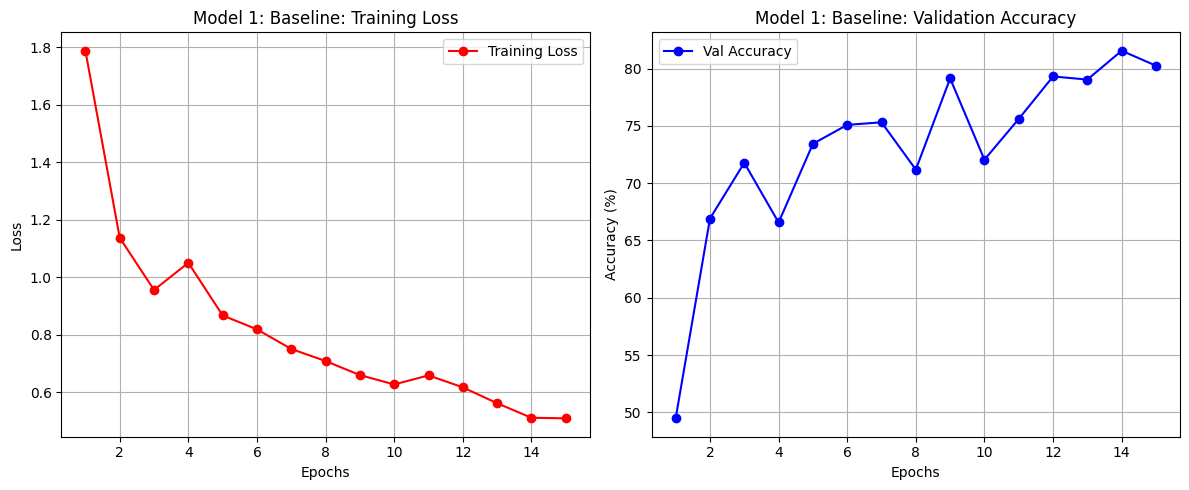

In [27]:
plot_learning_curves(history1, "Model 1: Baseline")

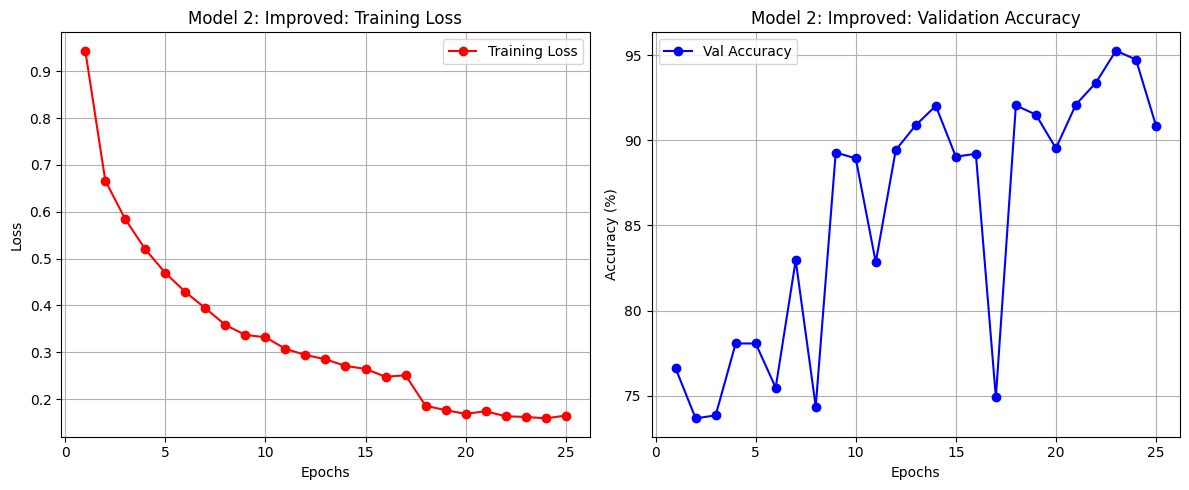

In [28]:
plot_learning_curves(history2, "Model 2: Improved")

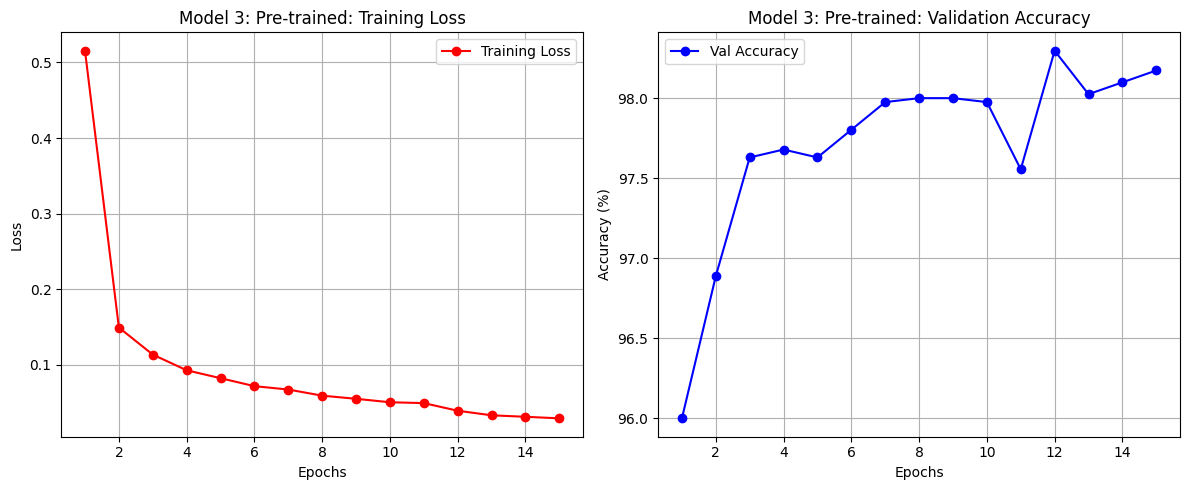

In [29]:
plot_learning_curves(history3, "Model 3: Pre-trained")